<a href="https://colab.research.google.com/github/Afif-Ghifari/PCVK_2025/blob/main/Week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>MODUL 11 DASAR-DASAR DETEKSI OBYEK</h1>
<hr>
<h2>Percobaan Praktikum</h2>

<b>Nama : Muhammad Afif Al Ghifari</b><br>
<b>Kelas: TI-3H</b><br>
<b>NIM  : 2341720168</b>

## D1. Praktikum Deteksi Obyek Dasar

### Object Detection

Metode yang digunakan:
1. Template matching
2. Edge detection
3. Corner detection
4. Grid detection
5. Contour detection

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Implementasikan 6 metode template matching pada OpenCV dengan
menggunakan gambar cats_and_bunnies.jpg dan cat2_templatejpg.jpg sebagai
templatenya.

### Template Matching
Menggunakan library openCV:<br>
cv.matchTemplate(), dengan parameter:
- image: citra input
- templ: template yang dicari, ukurannya tidak boleh lebih besar dari citra input
- method metode dari template matching


Jenis metode template matching di OpenCV:
1. TM_SQDIFF
2. TM_SQDIFF_NORMED
3. TM_CCORR
4. TM_CCORR_NORMED
5. TM_CCOEFF
6. TM_CCOEFF_NORMED

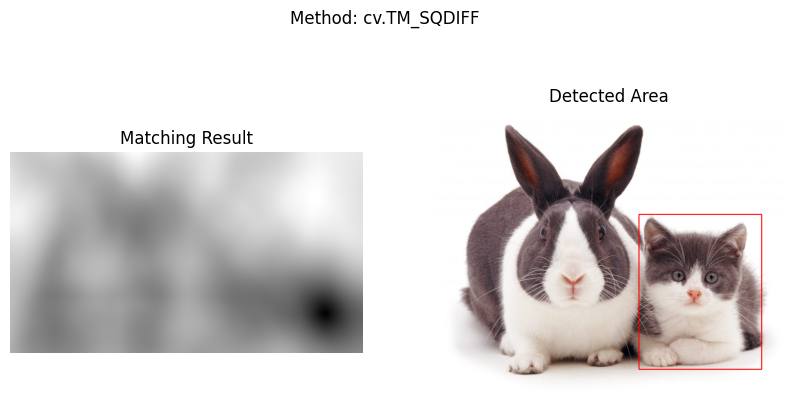

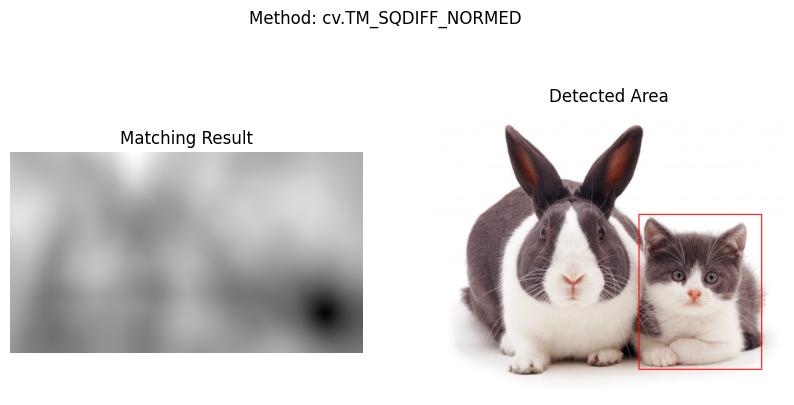

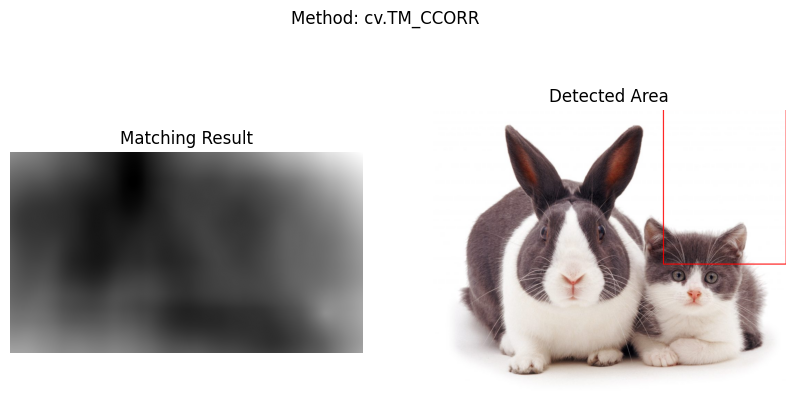

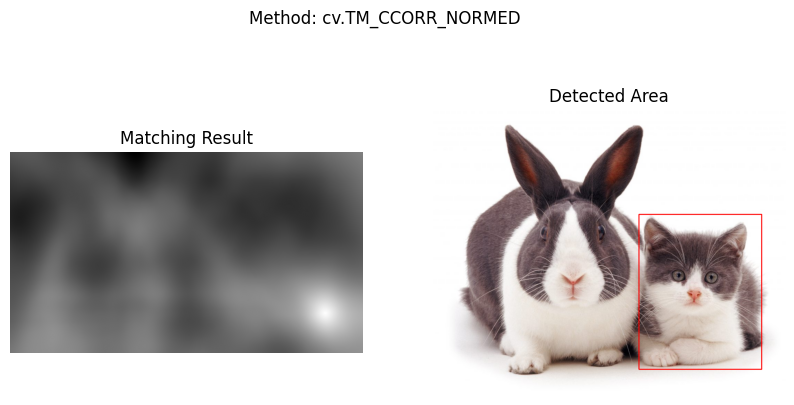

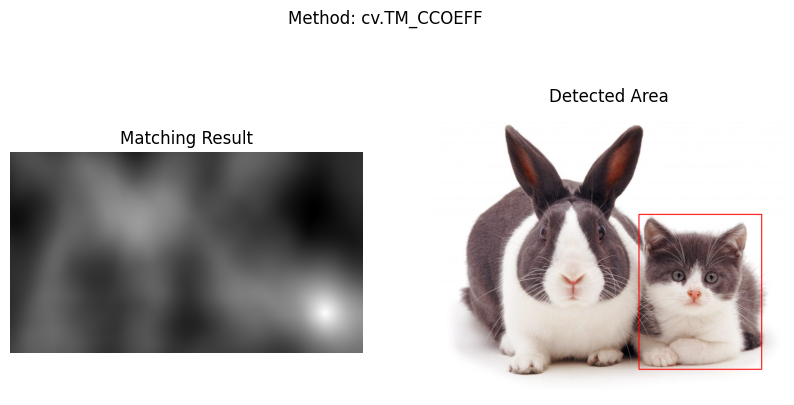

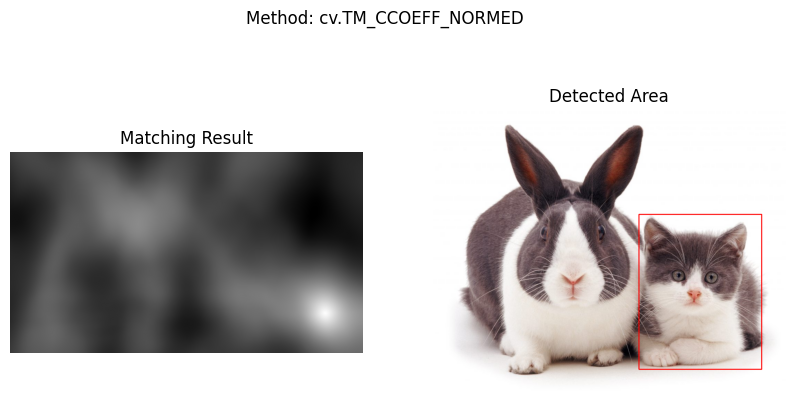

In [ ]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

# --- 1. Baca citra utama dan template ---
img = cv.imread('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/Object Detection/cats_and_bunnies.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
template = cv.imread('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/Object Detection/cat2_templatejpg.jpg', cv.IMREAD_GRAYSCALE)

# --- 2. Dapatkan ukuran template ---
w, h = template.shape[::-1]

# --- 3. Daftar metode template matching ---
methods = [
    'cv.TM_SQDIFF',
    'cv.TM_SQDIFF_NORMED',
    'cv.TM_CCORR',
    'cv.TM_CCORR_NORMED',
    'cv.TM_CCOEFF',
    'cv.TM_CCOEFF_NORMED'
]

# --- 4. Loop untuk setiap metode ---
for meth in methods:
    img_copy = img.copy()
    method = eval(meth)

    # --- Template Matching ---
    res = cv.matchTemplate(img_gray, template, method)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    # --- Tentukan lokasi terbaik ---
    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc

    bottom_right = (top_left[0] + w, top_left[1] + h)

    # --- Gambar kotak hasil pencocokan ---
    cv.rectangle(img_copy, top_left, bottom_right, (0, 0, 255), 2)

    # --- Tampilkan hasil ---
    plt.figure(figsize=(10,5))
    plt.suptitle(f'Method: {meth}')

    plt.subplot(1,2,1)
    plt.imshow(res, cmap='gray')
    plt.title('Matching Result')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(cv.cvtColor(img_copy, cv.COLOR_BGR2RGB))
    plt.title('Detected Area')
    plt.axis('off')

    plt.show()


Implementasikan konsep template matching tanpa menggunakan library OpenCV
untuk multiple object, menggunakan gambar bahrain.jpg untuk citra masukan dan
bahrain-template.jpg sebagai citra template, sehingga menghasilkan output
sebagai berikut:

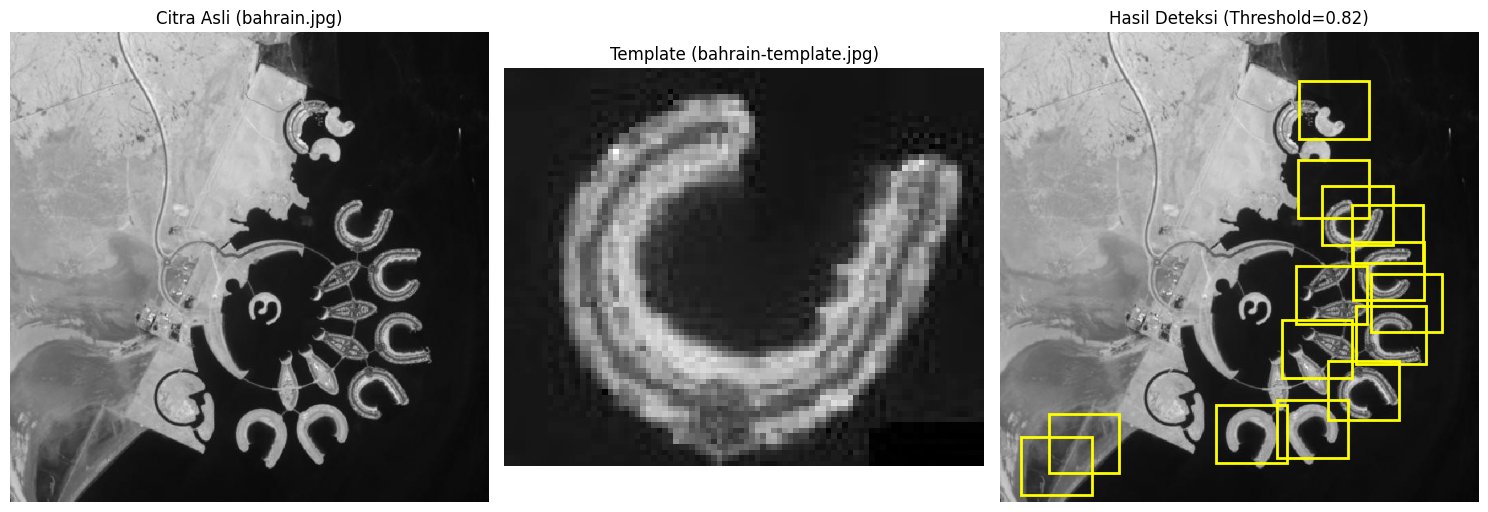

Jumlah objek terdeteksi: 14


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- 1. Load gambar utama dan template ---
img = np.array(Image.open('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/Object Detection/bahrain.jpg').convert('L'))       # grayscale
template = np.array(Image.open('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/Object Detection/bahrain-template.jpg').convert('L'))
th, tw = template.shape

# --- 2. Konversi ke float untuk perhitungan ---
img = img.astype(np.float32)
template = template.astype(np.float32)

# --- 3. Template Matching manual (Mean Squared Difference) ---
h, w = img.shape
result = np.zeros((h - th + 1, w - tw + 1), dtype=np.float32)

for y in range(h - th + 1):
    for x in range(w - tw + 1):
        patch = img[y:y+th, x:x+tw]
        diff = patch - template
        result[y, x] = np.sum(diff**2)

# --- 4. Normalisasi hasil (0–1), semakin kecil semakin mirip ---
result_norm = (result - np.min(result)) / (np.max(result) - np.min(result))
similarity = 1 - result_norm  # nilai tinggi berarti cocok

# --- 5. Threshold untuk multiple object detection ---
threshold = 0.82
y_coords, x_coords = np.where(similarity >= threshold)

# --- 6. Non-Maximum Suppression sederhana ---
selected_points = []
min_dist = tw // 2  # jarak minimum antar deteksi

for (y, x) in zip(y_coords, x_coords):
    if all(np.hypot(x - sx, y - sy) > min_dist for (sy, sx) in selected_points):
        selected_points.append((y, x))

# --- 7. Visualisasi hasil ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gambar asli
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Citra Asli (bahrain.jpg)')
axes[0].axis('off')

# Template
axes[1].imshow(template, cmap='gray')
axes[1].set_title('Template (bahrain-template.jpg)')
axes[1].axis('off')

# Hasil deteksi
axes[2].imshow(img, cmap='gray')
for (y, x) in selected_points:
    rect = plt.Rectangle((x, y), tw, th, edgecolor='yellow', facecolor='none', linewidth=2)
    axes[2].add_patch(rect)
axes[2].set_title(f'Hasil Deteksi (Threshold={threshold})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Jumlah objek terdeteksi: {len(selected_points)}")


Implementasikan metode Sobel Edge Detection, Canny Edge
Detection, dan Laplacian Edge Detection pada OpenCV dengan
menggunakan gambar car-park.jpg, sehingga menghasilkan luaran
sebagai berikut:

In [ ]:
img = cv.imread('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/Object Detection/car-park.jpg')
imgGray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
imgRgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

1. Sobel Edge Detection

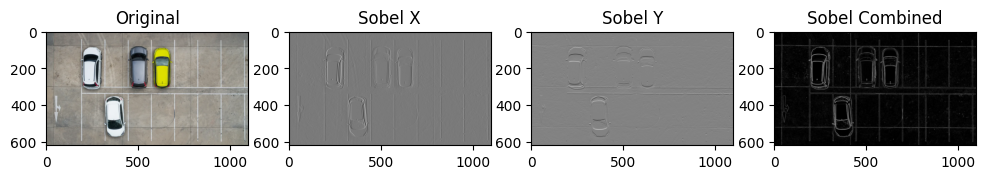

In [ ]:
# --- Sobel Edge Detection ---
sobelx = cv.Sobel(imgGray, cv.CV_64F, 1, 0, ksize=3)  # arah X
sobely = cv.Sobel(imgGray, cv.CV_64F, 0, 1, ksize=3)  # arah Y
sobel_combined = cv.magnitude(sobelx, sobely)     # magnitude gradient

# --- Tampilkan hasil ---
plt.figure(figsize=(12,4))
plt.subplot(1,4,1), plt.imshow(imgRgb), plt.title('Original')
plt.subplot(1,4,2), plt.imshow(sobelx, cmap='gray'), plt.title('Sobel X')
plt.subplot(1,4,3), plt.imshow(sobely, cmap='gray'), plt.title('Sobel Y')
plt.subplot(1,4,4), plt.imshow(sobel_combined, cmap='gray'), plt.title('Sobel Combined')
plt.show()

2. Canny Edge Detection

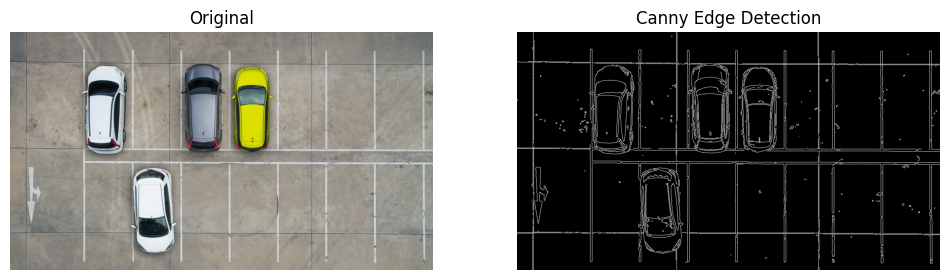

In [ ]:
# --- Canny Edge Detection ---
edges = cv.Canny(imgGray, 100, 200)  # parameter = threshold1, threshold2

# --- Tampilkan hasil ---
plt.figure(figsize=(12,4))

plt.subplot(1,2,1), plt.imshow(imgRgb), plt.title('Original'), plt.axis('off')
plt.subplot(1,2,2), plt.imshow(edges, cmap='gray'), plt.title('Canny Edge Detection'), plt.axis('off')
plt.show()

3. Laplacian Edge Detection

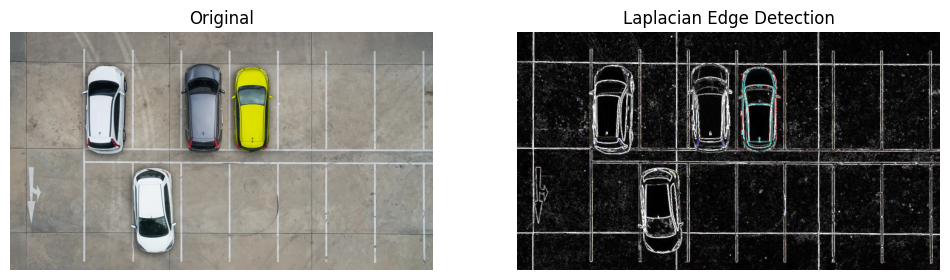

In [ ]:
# --- Laplacian Edge Detection ---
laplacian = cv.Laplacian(img, cv.CV_64F, ksize=3)
laplacian = cv.convertScaleAbs(laplacian)  # konversi ke nilai absolut 8-bit

# --- Tampilkan hasil ---
plt.figure(figsize=(12,4))

plt.subplot(1,2,1), plt.imshow(imgRgb), plt.title('Original'), plt.axis('off')
plt.subplot(1,2,2), plt.imshow(laplacian, cmap='gray'), plt.title('Laplacian Edge Detection'), plt.axis('off')
plt.show()

Implementasikan metode Harris Corner Detection dan Shi-Tomasi
Detection pada OpenCV dengan menggunakan gambar chess
board.jpg, sehingga menghasilkan luaran sebagai berikut:

- Harris Corner Detection

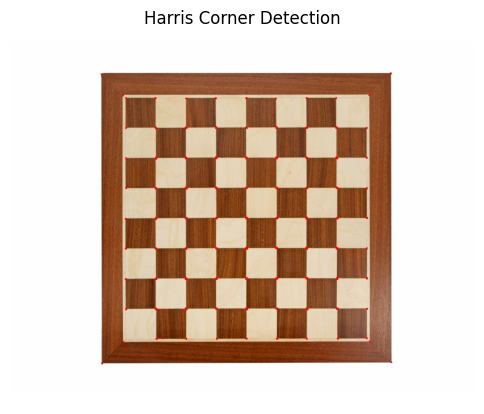

In [ ]:
# --- Baca gambar dan ubah ke grayscale ---
img = cv2.imread('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/Object Detection/chess-board.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

# --- Harris Corner Detection ---
dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# --- Dilasi agar sudut lebih terlihat ---
dst = cv2.dilate(dst, None)

# --- Tandai sudut pada gambar ---
img_harris = img.copy()
img_harris[dst > 0.01 * dst.max()] = [0, 0, 255]  # warna merah untuk corner

# --- Tampilkan hasil ---
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img_harris, cv2.COLOR_BGR2RGB))
plt.title('Harris Corner Detection')
plt.axis('off')
plt.show()


- Shi-Tomasi Detection

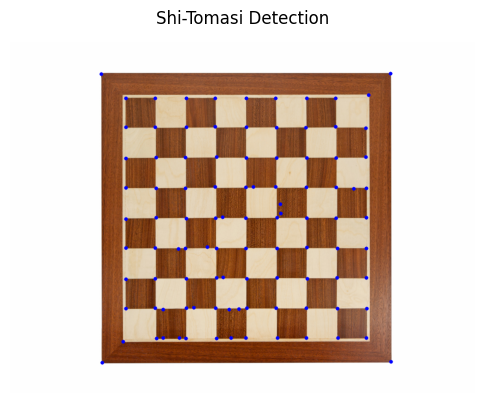

In [ ]:
# --- Shi-Tomasi (Good Features to Track) ---
img = cv2.imread('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/Object Detection/chess-board.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

corners = cv2.goodFeaturesToTrack(
    gray,
    maxCorners=100,
    qualityLevel=0.01,
    minDistance=10
)

# Konversi hasil ke integer
corners = corners.astype(np.intp)

# --- Gambar titik corner pada citra ---
img_shitomasi = img.copy()
for i in corners:
    x, y = i.ravel()
    cv2.circle(img_shitomasi, (x, y), 4, (255, 0, 0), -1)

# --- Tampilkan hasil ---
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img_shitomasi, cv2.COLOR_BGR2RGB))
plt.title('Shi-Tomasi Detection')
plt.axis('off')
plt.show()

Implementasikan metode Hough Transform pada OpenCV dengan
menggunakan gambar sudoku.jpg. Tahapan proses grid detection sesuai yang
terdapat pada ulasan teori, sehingga menghasilkan luaran sebagai berikut:

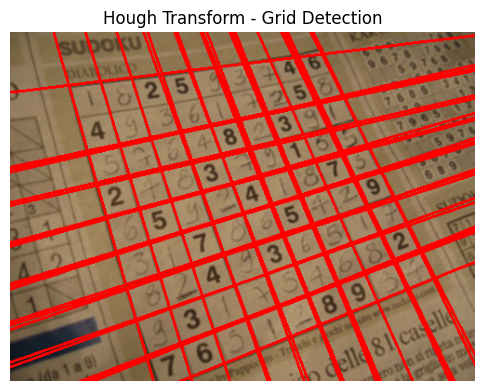

In [ ]:
# --- 1. Baca gambar ---
img = cv2.imread('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/Object Detection/sudoku.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- 2. Deteksi tepi dengan Canny ---
edges = cv2.Canny(gray, 60, 250, apertureSize=3)

# --- 3. Hough Transform untuk deteksi garis ---
lines = cv2.HoughLines(edges, 1, np.pi/180, 150)  # parameter terakhir = threshold

# --- 4. Gambar garis pada gambar asli ---
img_hough = img.copy()

if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(img_hough, (x1, y1), (x2, y2), (0, 0, 255), 2)  # garis merah

# --- 5. Tampilkan hasil ---
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(img_hough, cv2.COLOR_BGR2RGB))
plt.title('Hough Transform - Grid Detection')
plt.axis('off')
plt.show()

Implementasikan fungsi findContours() pada OpenCV untuk contour detection
dengan menggunakan gambar laptop.jpg, sehingga menghasilkan luaran
sebagai berikut:

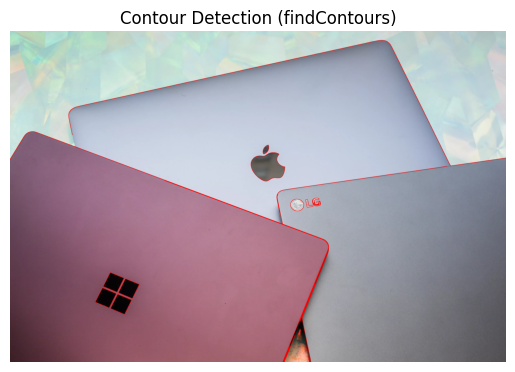

In [ ]:
# --- 1. Baca gambar ---
img = cv2.imread('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/Object Detection/laptop.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5, 5), 0)

edges = cv2.Canny(blur, 50, 150)

contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contour_img = img.copy()
cv2.drawContours(contour_img, contours, -1, (0, 0, 255), 2)

plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
plt.title('Contour Detection (findContours)')
plt.axis('off')

plt.show()

# D2. Praktikum Feature Matching dan Face Detection

 Lakukan Face Detection untuk image object lain yang tersedia pada
(/images/facedet). Tampilkan seperti pada contoh berikut.

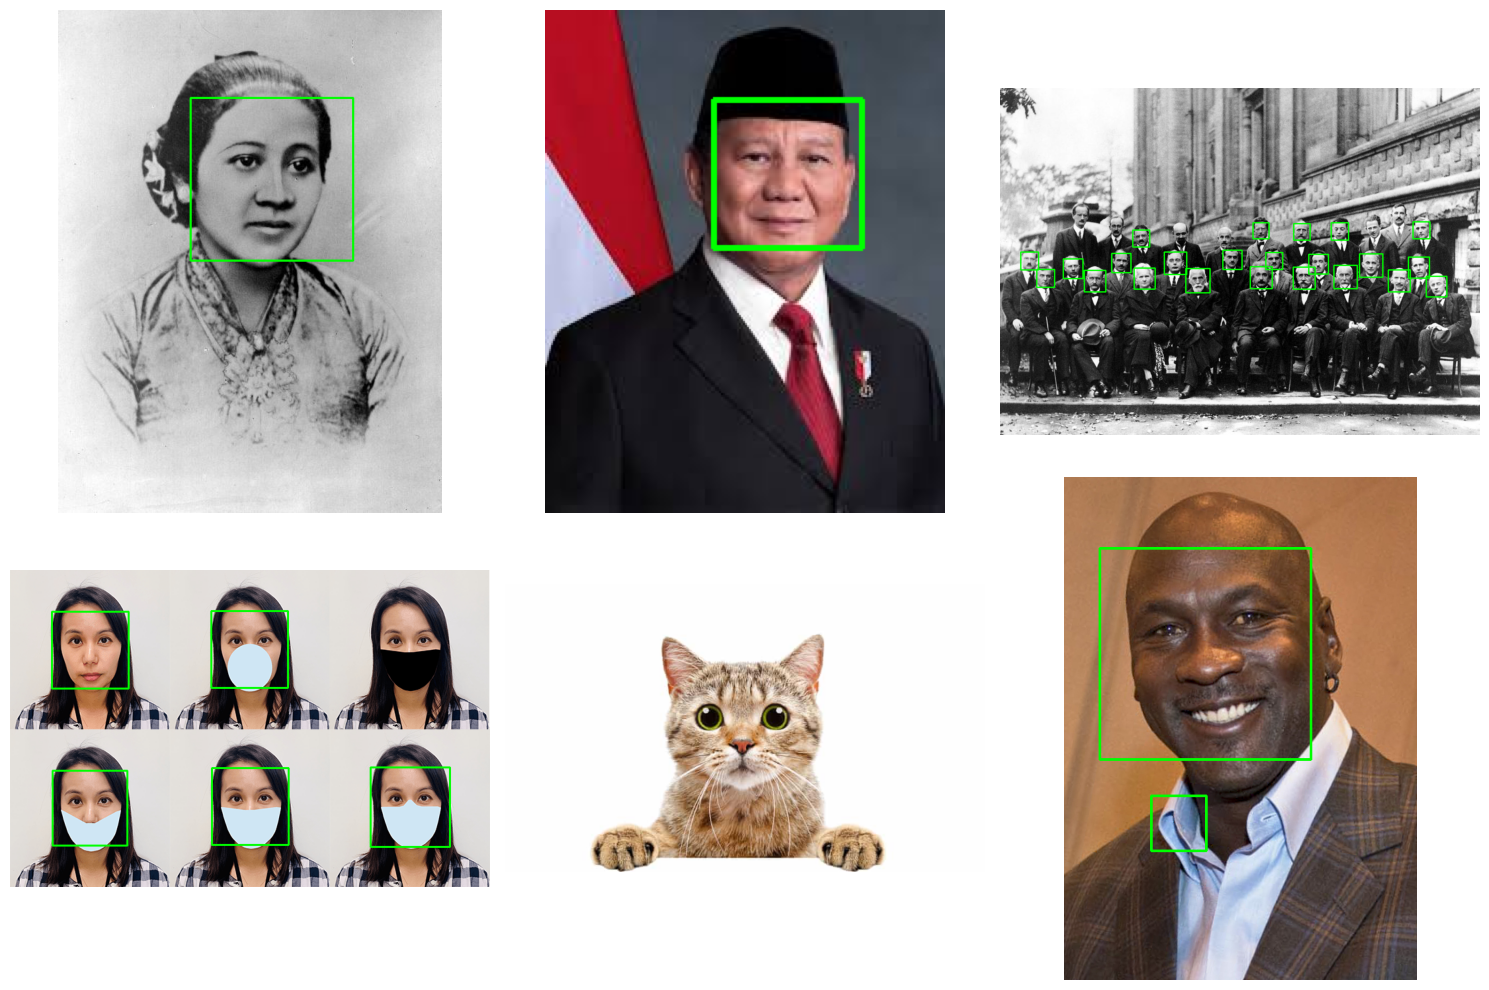

In [ ]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

image_paths = [
    r"/content/drive/MyDrive/kuliah/pcvk/asset pcvk/facedet/kartini.jpg",
    r"/content/drive/MyDrive/kuliah/pcvk/asset pcvk/facedet/prabowo.jpg",
    r"/content/drive/MyDrive/kuliah/pcvk/asset pcvk/facedet/solvayconf.jpg",
    r"/content/drive/MyDrive/kuliah/pcvk/asset pcvk/facedet/mask.png",
    r"/content/drive/MyDrive/kuliah/pcvk/asset pcvk/facedet/kucing.jpg",
    r"/content/drive/MyDrive/kuliah/pcvk/asset pcvk/facedet/mjordan.jpg"
]


plt.figure(figsize=(15, 10))

for i, path in enumerate(image_paths, start=1):
    img = cv2.imread(str(path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))

    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Tampilkan hasil
    plt.subplot(2, 3, i)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()

Pada Soal No.2. wajah kucing tidak bisa dideteksi dengan baik. Lakukan deteksi
wajah kucing hingga muncul rectangle pada bagian wajahnya. Petunjuk pada soal
ini, perhatikan pretrained features yang telah disediakan OpenCV. Gunakan xml
yang ada jika memang telah disediakan. Jika belum ada, coba cari dengan
searching melalui search engines.

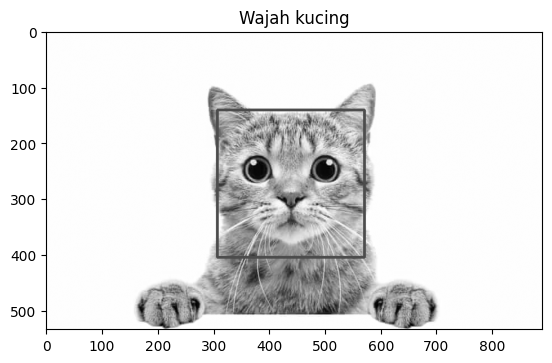

In [ ]:
cat_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalcatface.xml')

# Baca gambar
img = cv2.imread('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/facedet/kucing.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Deteksi wajah kucing
cats = cat_cascade.detectMultiScale(
    gray,
    scaleFactor=1.07,
    minNeighbors=5,
    minSize=(75, 75)
)

# Gambar persegi di area wajah
for (x, y, w, h) in cats:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 255), 3)

# Tampilkan hasil
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cmap='gray')
plt.title(f"Wajah kucing")
plt.show()

Cobakan juga untuk eyes detection pada wajah Pak Prabowo:

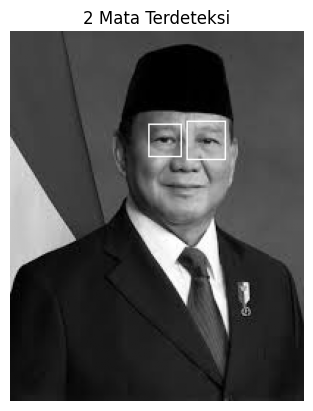

In [ ]:
eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Baca gambar
img = cv2.imread('/content/drive/MyDrive/kuliah/pcvk/asset pcvk/facedet/prabowo.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Deteksi mata
eyes = eye_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=3,
    minSize=(20, 20)
)

# Gambar kotak di area mata
for (x, y, w, h) in eyes:
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 255, 255), 1)

# Tampilkan hasil
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cmap='gray')
plt.axis('off')
plt.title(f"{len(eyes)} Mata Terdeteksi")
plt.show()

Lakukan deteksi senyuman pada gambar people:

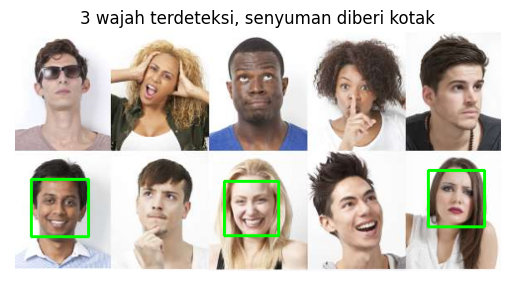

In [ ]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

img = cv2.imread('/content/people.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.3, 20)

for (x, y, w, h) in faces:
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]

    smiles = smile_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.7,
        minNeighbors=22,
        minSize=(25, 25)
    )


    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)

    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 255, 0), 1)

# Tampilkan hasil
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"{len(faces)} wajah terdeteksi, senyuman diberi kotak")
plt.show()

 Lakukan Face Tracking menggunakan Google Colab. Petunjuk, Tutorial
selengkapnya tentang akses kamera dan FaceDetection pada google colab dapat
dilihat di link berikut: https://www.youtube.com/watch?v=YjWh7QvVH60

In [ ]:
# import dependencies
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import numpy as np
import PIL
import io
import html
import time

In [ ]:
# function to convert the JavaScript object into an OpenCV image
def js_to_image(js_reply):
  """
  Params:
          js_reply: JavaScript object containing image from webcam
  Returns:
          img: OpenCV BGR image
  """
  # decode base64 image
  image_bytes = b64decode(js_reply.split(',')[1])
  # convert bytes to numpy array
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  # decode numpy array into OpenCV BGR image
  img = cv2.imdecode(jpg_as_np, flags=1)

  return img

# function to convert OpenCV Rectangle bounding box image into base64 byte string to be overlayed on video stream
def bbox_to_bytes(bbox_array):
  """
  Params:
          bbox_array: Numpy array (pixels) containing rectangle to overlay on video stream.
  Returns:
        bytes: Base64 image byte string
  """
  # convert array into PIL image
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
  iobuf = io.BytesIO()
  # format bbox into png for return
  bbox_PIL.save(iobuf, format='png')
  # format return string
  bbox_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))

  return bbox_bytes

In [ ]:
# initialize the Haar Cascade face detection model
face_cascade = cv2.CascadeClassifier(cv2.samples.findFile(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'))

In [ ]:
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)

  # get photo data
  data = eval_js('takePhoto({})'.format(quality))
  # get OpenCV format image
  img = js_to_image(data)
  # grayscale img
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  print(gray.shape)
  # get face bounding box coordinates using Haar Cascade
  faces = face_cascade.detectMultiScale(gray)
  # draw face bounding box on image
  for (x,y,w,h) in faces:
      img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
  # save image
  cv2.imwrite(filename, img)

  return filename

<IPython.core.display.Javascript object>

(480, 640)
Saved to photo.jpg


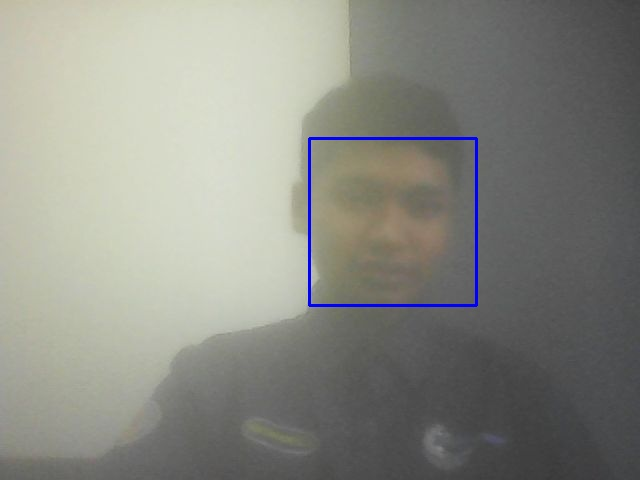

In [ ]:
try:
  filename = take_photo('photo.jpg')
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

Lakukan Blurring pada bagian wajah yang terdeteksi. Berikut contoh keluarannya.
Petunjuk: anda dapat menggunakan cv.medianBlur untuk melakukan Blurring

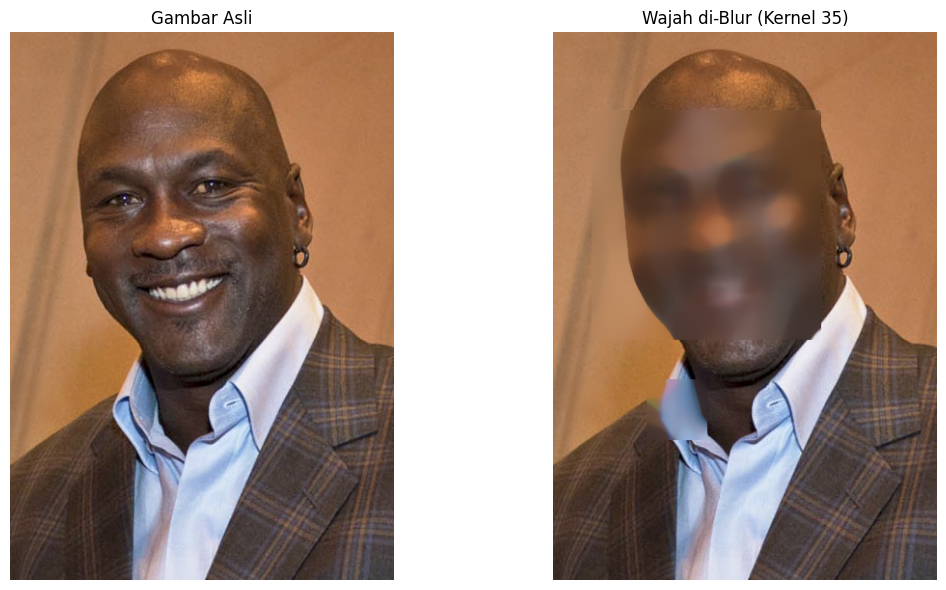

In [ ]:
path_image = r"/content/drive/MyDrive/kuliah/pcvk/asset pcvk/facedet/mjordan.jpg"

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

img = cv2.imread(path_image)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(50, 50))

img_blurred = img.copy()

kernel_size = 35
for (x, y, w, h) in faces:
    roi_face = img_blurred[y:y+h, x:x+w]
    blurred_face = cv2.medianBlur(roi_face, kernel_size)
    img_blurred[y:y+h, x:x+w] = blurred_face

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_blurred_rgb = cv2.cvtColor(img_blurred, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_blurred_rgb)
plt.title(f"Wajah di-Blur (Kernel {kernel_size})")
plt.axis('off')

plt.tight_layout()
plt.show()


Mengolah gambar KTM masing-masing


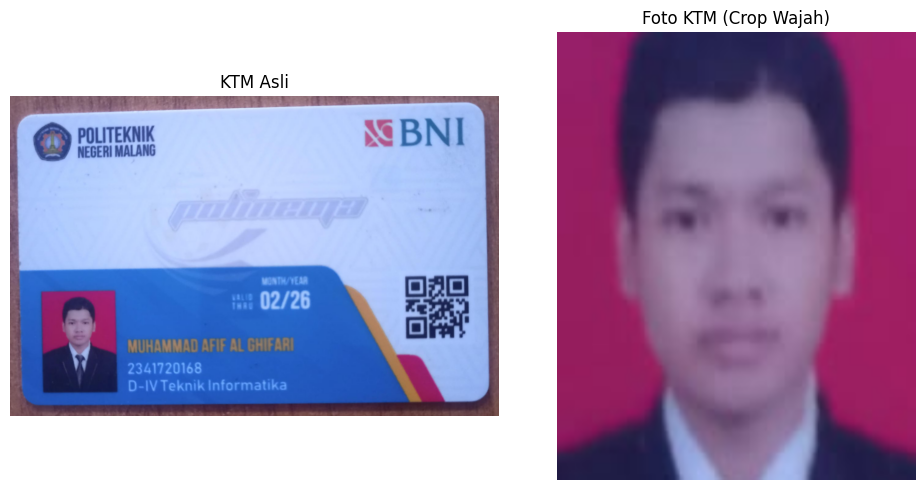

In [ ]:
# 1. Load model deteksi wajah
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_alt.xml')

# 2. Baca gambar KTM
path_image = r"/content/ktmAfif.jpeg"
img = cv2.imread(path_image)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Deteksi wajah
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

# 4. Jika wajah ditemukan, crop dan tampilkan
for (x, y, w, h) in faces:
    # Tambahkan margin agar wajah tidak terpotong
    pad_x, pad_y = int(w * 0.2), int(h * 0.2)
    y1, y2 = max(0, y - pad_y), min(img.shape[0], y + h + pad_y)
    x1, x2 = max(0, x - pad_x), min(img.shape[1], x + w + pad_x)

    # Crop wajah dan ubah ukurannya
    crop_face = img[y1:y2, x1:x2]
    crop_resized = cv2.resize(crop_face, (400, 500))

    # 5. Tampilkan hasil
    plt.figure(figsize=(10, 5))

    # Gambar asli
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('KTM Asli')
    plt.axis('off')

    # Hasil crop wajah
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(crop_resized, cv2.COLOR_BGR2RGB))
    plt.title('Foto KTM (Crop Wajah)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Tambahan Tugas Praktikum:

Tampilkan karakter-karakter pada KTM ini Deep Learning untuk melakukan
pengenalan karakter. Sebelum melakukan training data, terlebih dahulu di
siapkan data yang akan dilakukan training yaitu data image nomor angka 0-9.
Untuk membuat data tersebut bisa gunakan image editor untuk dilakukan croping
satu persatu. Kemudian selanjutnya gunakan source code di bawah ini untuk
proses persiapan untuk training.

In [ ]:
import cv2, os, numpy as np

test_dir = "/content/drive/MyDrive/kuliah/pcvk/asset pcvk/ANGKA/"
files = os.listdir(test_dir)
print("Jumlah file:", len(files))
img = cv2.imread(os.path.join(test_dir, files[0]), cv2.IMREAD_GRAYSCALE)
print("Shape gambar:", None if img is None else img.shape)


Jumlah file: 8500
Shape gambar: (234, 146)


In [ ]:
import os
import cv2
import random
import numpy as np
import pickle
from tqdm import tqdm

DATADIR = "/content/drive/MyDrive/kuliah/pcvk/asset pcvk/ANGKA"
training_data = []
width, height = 100, 100

for img in tqdm(os.listdir(DATADIR), desc="Processing images"):
    try:
        img_array = cv2.imread(os.path.join(DATADIR, img), cv2.IMREAD_GRAYSCALE)
        new_array = cv2.resize(img_array, (width, height))
        training_data.append([new_array, 0])  # semua label = 0
    except Exception as e:
        print(f"Error {img}: {e}")

random.shuffle(training_data)

X = []
Y = []

for feature, label in training_data:
    X.append(feature)
    Y.append(label)

X = np.array(X).reshape(-1, width, height, 1)

with open("X.pickle", "wb") as f:
    pickle.dump(X, f)
with open("Y.pickle", "wb") as f:
    pickle.dump(Y, f)

print("X shape:", X.shape)
print("Y length:", len(Y))


Processing images: 100%|██████████| 8500/8500 [1:06:15<00:00,  2.14it/s]

X shape: (8500, 100, 100, 1)
Y length: 8500


In [ ]:
pip install keras

In [ ]:
import pickle
from google.colab import files
X = pickle.load(open("X.pickle", "rb"))
Y = pickle.load(open("Y.pickle", "rb"))
print("X shape:", getattr(X, "shape", None))
print("Y length:", len(Y))

files.download("X.pickle")
files.download("Y.pickle")

X shape: (8500, 100, 100, 1)
Y length: 8500


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pip install --upgrade tensorflow


In [ ]:
import pickle
import numpy as np
from tensorflow import keras
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, ZeroPadding2D
from keras.models import Model
from keras.optimizers import Adam
from keras.utils import to_categorical

# Load file pickle
with open("X.pickle", "rb") as f:
    X = pickle.load(f)

with open("Y.pickle", "rb") as f:
    Y = pickle.load(f)

# Normalisasi dan kategorisasi
X = X / 255.0
Y = np.array(Y).reshape(-1)
Y = to_categorical(Y, num_classes=34)

width, height = 100, 100

# Model
inputs = Input(shape=(width, height, 1))
x = ZeroPadding2D(padding=(2, 2))(inputs)
x = Conv2D(16, (5, 5), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu')(x)
x = Conv2D(32, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(34, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X, Y, epochs=20, verbose=1)
model.save('anpr.keras')


Epoch 1/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.9769 - loss: 0.3431
Epoch 2/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 1.0000 - loss: 1.9957e-06
Epoch 3/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 1.0000 - loss: 9.2952e-07
Epoch 4/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 1.0000 - loss: 5.2083e-07
Epoch 5/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 1.0000 - loss: 3.0278e-07
Epoch 6/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 1.0000 - loss: 1.3818e-07
Epoch 7/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 1.0000 - loss: 9.3289e-08
Epoch 8/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 1.0000 - loss: 6.2781e-08
Epoch 9/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 1.0000 - loss: 6.2005e-08
Epoch 10/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 1.0000 - loss: 2.7759e-08
Epoch 11/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 1.0000 - loss: 2.9154e-08
Epoch 

In [ ]:
conv_layer = ZeroPadding2D(padding=(2, 2))(inputs)
conv_layer = Conv2D(16, (5, 5), strides=(1, 1),
activation='relu')(conv_layer)
conv_layer = MaxPooling2D((2, 2))(conv_layer)
conv_layer = Conv2D(32, (3, 3), strides=(1, 1),
activation='relu')(conv_layer)
conv_layer = Conv2D(32, (3, 3), strides=(1, 1),
activation='relu')(conv_layer)
conv_layer = MaxPooling2D((2, 2))(conv_layer)
conv_layer = Conv2D(64, (3, 3), strides=(1, 1),
activation='relu')(conv_layer)

In [ ]:
import cv2
import numpy as np
import tensorflow as tf

# Muat model
model = tf.keras.models.load_model("anpr.keras")

# Daftar label sesuai urutan training
dirs = [
    "0", "1", "2", "3", "4", "5", "6", "7", "8", "9",
]

# Baca gambar KTM
img = cv2.imread("ktmAfifNIM.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Preprocessing
blur = cv2.GaussianBlur(gray, (3,3), 0)
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Hilangkan noise kecil
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Temukan kontur
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Jumlah kontur ditemukan: {len(contours)}")

# Urutkan kontur dari kiri ke kanan
contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])

width, height = 100, 100
predicted_text = ""

for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    if 50 < w*h < 20000 and h > 20 and w > 5:
        # Gambarkan kotak hijau untuk debugging
        cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)
        char = gray[y:y+h, x:x+w]
        char = cv2.resize(char, (width, height))
        char = char.reshape(-1, width, height, 1) / 255.0

        prediction = model.predict(char, verbose=0)
        predicted_label = dirs[np.argmax(prediction[0])]
        predicted_text += predicted_label

print("Hasil OCR KTM:", predicted_text)

# # Tampilkan hasil preprocessing dan bounding box
# cv2.imshow("Gray", gray)
# cv2.imshow("Threshold", thresh)
# cv2.imshow("Detected Characters", img)


Jumlah kontur ditemukan: 1
Hasil OCR KTM: 
